# Comprehensive Model Comparison: Optic Disc/Cup Segmentation

This notebook evaluates and compares five different approaches for optic disc and cup segmentation on the test dataset.

**Approaches:**
1. **Baseline UNet** - Standard UNet architecture
2. **CLAHE** - UNet trained with CLAHE preprocessing
3. **Baseline + Std Enhancer** - UNet with learned standard enhancer
4. **Baseline + Atrous Enhancer** - UNet with learned multi-scale enhancer
5. **ASPP Unet** - UNet with Atrous Spatial Pyramid Pooling

**Metrics:**
- Loss, IoU BG, IoU Disc, IoU Cup, mIoU, Parameters, Δ mIoU

## 1. Setup and Imports

In [1]:
import sys
from pathlib import Path
import json
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import pandas as pd

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from data_loader.dataset import GlaucomaDataset
from data_loader.transforms import get_validation_transforms
from models.unet import UNet
from models.aspp_unet import ASPPUNet
from models.enhancer import ImageEnhancer
from models.atrous_enhancer import AtrousImageEnhancer, LightweightAtrousEnhancer
from training.train import CombinedLoss, DiceLoss
from training.train_enhancer import EnhancerUNetModel

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
Using device: cuda


## 2. Load Test Dataset

In [2]:
# Load test dataset
test_transforms = get_validation_transforms(image_size=256, use_clahe=False)
test_dataset = GlaucomaDataset(
    root_dir=str(project_root),
    split='test',
    transform=test_transforms,
    seed=42,
    filter_incomplete=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Test dataset: {len(test_dataset)} samples")
print(f"Test loader: {len(test_loader)} batches")

Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TEST split: 396 samples
Test dataset: 396 samples
Test loader: 25 batches


## 14. Save Results to JSON

In [3]:
def load_model_from_checkpoint(checkpoint_path, model_class, **model_kwargs):
    """Load model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    if 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint

    model = model_class(**model_kwargs)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    return model

# Model configurations
models = {}

# 1. Baseline UNet
print("Loading Baseline UNet...")
models['baseline_unet'] = load_model_from_checkpoint(
    project_root / 'checkpoints' / 'best_model.pth',
    UNet,
    n_channels=3, n_classes=3, base_channels=64
)

# 2. CLAHE (UNet trained with CLAHE preprocessing)
print("Loading CLAHE UNet...")
models['clahe'] = load_model_from_checkpoint(
    project_root / 'checkpoints_clahe' / 'best_model.pth',
    UNet,
    n_channels=3, n_classes=3, base_channels=64
)

# 3. Baseline + Std Enhancer (joint model)
print("Loading Standard Enhancer + UNet...")
enhancer = ImageEnhancer()
unet = UNet(n_channels=3, n_classes=3, base_channels=64)
joint_model = EnhancerUNetModel(enhancer, unet)

checkpoint = torch.load(project_root / 'checkpoints_enhancer' / 'phase2_best_model.pth',
                       map_location='cpu', weights_only=False)
joint_model.load_state_dict(checkpoint['model_state_dict'])
joint_model = joint_model.to(device)
joint_model.eval()
models['std_enhancer'] = joint_model

# 4. Baseline + Atrous Enhancer (joint model)
print("Loading Atrous Enhancer + UNet...")
atrous_enhancer = LightweightAtrousEnhancer(base_channels=24, residual_weight=0.3)
unet = UNet(n_channels=3, n_classes=3, base_channels=64)
joint_model = EnhancerUNetModel(atrous_enhancer, unet)

checkpoint = torch.load(project_root / 'checkpoints_atrous_enhancer' / 'phase2_best_model.pth',
                       map_location='cpu', weights_only=False)
joint_model.load_state_dict(checkpoint['model_state_dict'])
joint_model = joint_model.to(device)
joint_model.eval()
models['atrous_enhancer'] = joint_model

# 5. ASPP Unet
print("Loading ASPP-UNet...")
models['aspp_unet'] = load_model_from_checkpoint(
    project_root / 'checkpoints_aspp_unet' / 'best_model.pth',
    ASPPUNet,
    n_channels=3, n_classes=3, base_channels=64
)

print(f"Loaded {len(models)} models successfully!")

Loading Baseline UNet...
Loading CLAHE UNet...
Loading Standard Enhancer + UNet...
Loading Atrous Enhancer + UNet...
Loading ASPP-UNet...
Loaded 5 models successfully!


## 4. Define Evaluation Function

In [4]:
def count_parameters(model):
    """Count total parameters in model"""
    return sum(p.numel() for p in model.parameters())

def calculate_iou_per_class(pred, target, num_classes=3):
    """Calculate IoU for each class"""
    ious = []
    for cls in range(num_classes):
        pred_cls = (pred == cls)
        target_cls = (target == cls)

        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()

        if union > 0:
            iou = intersection / union
        else:
            iou = torch.tensor(1.0)  # Perfect score if no pixels of this class

        ious.append(iou.item())

    return ious

def evaluate_model(model, test_loader, is_enhancer_model=False):
    """Evaluate model on test dataset"""
    model = model.to(device)

    # Loss function
    class_weights = torch.tensor([1.0, 1.0, 2.0]).to(device)  # Cup weight = 2.0
    criterion = CombinedLoss(
        ce_weight=0.5,
        dice_weight=0.5,
        class_weights=class_weights,
        device=device
    )

    model.eval()
    total_loss = 0
    total_iou_bg = 0
    total_iou_disc = 0
    total_iou_cup = 0
    num_samples = 0

    with torch.no_grad():
        for images, masks in tqdm(test_loader, desc='Evaluating'):
            images = images.to(device)
            masks = masks.to(device)

            if is_enhancer_model:
                # For enhancer models, get both enhanced image and segmentation
                enhanced, outputs = model(images)
            else:
                # For regular models, just get segmentation
                outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)

            # Get predictions
            pred = torch.argmax(outputs, dim=1)  # [B, H, W]

            # Calculate IoU per class for each sample
            for i in range(images.size(0)):
                ious = calculate_iou_per_class(pred[i], masks[i])
                total_iou_bg += ious[0]
                total_iou_disc += ious[1]
                total_iou_cup += ious[2]

            num_samples += images.size(0)

    # Average metrics
    avg_loss = total_loss / num_samples
    avg_iou_bg = total_iou_bg / num_samples
    avg_iou_disc = total_iou_disc / num_samples
    avg_iou_cup = total_iou_cup / num_samples
    miou = (avg_iou_bg + avg_iou_disc + avg_iou_cup) / 3

    return {
        'loss': avg_loss,
        'iou_bg': avg_iou_bg,
        'iou_disc': avg_iou_disc,
        'iou_cup': avg_iou_cup,
        'miou': miou
    }

## 5. Evaluate Baseline UNet

In [5]:
# Evaluate Baseline UNet
print("Evaluating Baseline UNet...")
baseline_results = evaluate_model(models['baseline_unet'], test_loader, is_enhancer_model=False)
baseline_results['parameters'] = count_parameters(models['baseline_unet'])
baseline_results['delta_miou'] = 0.0  # Reference model

print("Baseline UNet Results:")
print(f"  Loss: {baseline_results['loss']:.4f}")
print(f"  IoU BG: {baseline_results['iou_bg']:.4f}")
print(f"  IoU Disc: {baseline_results['iou_disc']:.4f}")
print(f"  IoU Cup: {baseline_results['iou_cup']:.4f}")
print(f"  mIoU: {baseline_results['miou']:.4f}")
print(f"  Parameters: {baseline_results['parameters']:,}")
print(f"  Δ mIoU: {baseline_results['delta_miou']:.4f}")

Evaluating Baseline UNet...


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  7.46it/s]

Baseline UNet Results:
  Loss: 0.1647
  IoU BG: 0.8821
  IoU Disc: 0.8431
  IoU Cup: 0.7835
  mIoU: 0.8362
  Parameters: 31,043,651
  Δ mIoU: 0.0000


## 6. Evaluate CLAHE

In [6]:
# Evaluate CLAHE
print("Evaluating CLAHE...")
clahe_results = evaluate_model(models['clahe'], test_loader, is_enhancer_model=False)
clahe_results['parameters'] = count_parameters(models['clahe'])
clahe_results['delta_miou'] = clahe_results['miou'] - baseline_results['miou']

print("CLAHE Results:")
print(f"  Loss: {clahe_results['loss']:.4f}")
print(f"  IoU BG: {clahe_results['iou_bg']:.4f}")
print(f"  IoU Disc: {clahe_results['iou_disc']:.4f}")
print(f"  IoU Cup: {clahe_results['iou_cup']:.4f}")
print(f"  mIoU: {clahe_results['miou']:.4f}")
print(f"  Parameters: {clahe_results['parameters']:,}")
print(f"  Δ mIoU: {clahe_results['delta_miou']:.4f}")

Evaluating CLAHE...


Evaluating: 100%|██████████| 25/25 [00:02<00:00,  8.42it/s]

CLAHE Results:
  Loss: 0.3595
  IoU BG: 0.6703
  IoU Disc: 0.6747
  IoU Cup: 0.6353
  mIoU: 0.6601
  Parameters: 31,043,651
  Δ mIoU: -0.1761


## 7. Evaluate Baseline + Std Enhancer

In [7]:
# Evaluate Standard Enhancer
print("Evaluating Standard Enhancer...")
std_enhancer_results = evaluate_model(models['std_enhancer'], test_loader, is_enhancer_model=True)
std_enhancer_results['parameters'] = count_parameters(models['std_enhancer'])
std_enhancer_results['delta_miou'] = std_enhancer_results['miou'] - baseline_results['miou']

print("Standard Enhancer Results:")
print(f"  Loss: {std_enhancer_results['loss']:.4f}")
print(f"  IoU BG: {std_enhancer_results['iou_bg']:.4f}")
print(f"  IoU Disc: {std_enhancer_results['iou_disc']:.4f}")
print(f"  IoU Cup: {std_enhancer_results['iou_cup']:.4f}")
print(f"  mIoU: {std_enhancer_results['miou']:.4f}")
print(f"  Parameters: {std_enhancer_results['parameters']:,}")
print(f"  Δ mIoU: {std_enhancer_results['delta_miou']:.4f}")

Evaluating Standard Enhancer...


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  7.08it/s]

Standard Enhancer Results:
  Loss: 0.1638
  IoU BG: 0.8831
  IoU Disc: 0.8436
  IoU Cup: 0.7841
  mIoU: 0.8369
  Parameters: 31,993,126
  Δ mIoU: 0.0007


## 8. Evaluate Baseline + Atrous Enhancer

In [8]:
# Evaluate Atrous Enhancer
print("Evaluating Atrous Enhancer...")
atrous_enhancer_results = evaluate_model(models['atrous_enhancer'], test_loader, is_enhancer_model=True)
atrous_enhancer_results['parameters'] = count_parameters(models['atrous_enhancer'])
atrous_enhancer_results['delta_miou'] = atrous_enhancer_results['miou'] - baseline_results['miou']

print("Atrous Enhancer Results:")
print(f"  Loss: {atrous_enhancer_results['loss']:.4f}")
print(f"  IoU BG: {atrous_enhancer_results['iou_bg']:.4f}")
print(f"  IoU Disc: {atrous_enhancer_results['iou_disc']:.4f}")
print(f"  IoU Cup: {atrous_enhancer_results['iou_cup']:.4f}")
print(f"  mIoU: {atrous_enhancer_results['miou']:.4f}")
print(f"  Parameters: {atrous_enhancer_results['parameters']:,}")
print(f"  Δ mIoU: {atrous_enhancer_results['delta_miou']:.4f}")

Evaluating Atrous Enhancer...


Evaluating: 100%|██████████| 25/25 [00:03<00:00,  7.31it/s]

Atrous Enhancer Results:
  Loss: 0.1698
  IoU BG: 0.8793
  IoU Disc: 0.8392
  IoU Cup: 0.7796
  mIoU: 0.8327
  Parameters: 31,069,526
  Δ mIoU: -0.0035


## 9. Evaluate ASPP Unet

In [9]:
# Evaluate ASPP-UNet
print("Evaluating ASPP-UNet...")
aspp_results = evaluate_model(models['aspp_unet'], test_loader, is_enhancer_model=False)
aspp_results['parameters'] = count_parameters(models['aspp_unet'])
aspp_results['delta_miou'] = aspp_results['miou'] - baseline_results['miou']

print("ASPP-UNet Results:")
print(f"  Loss: {aspp_results['loss']:.4f}")
print(f"  IoU BG: {aspp_results['iou_bg']:.4f}")
print(f"  IoU Disc: {aspp_results['iou_disc']:.4f}")
print(f"  IoU Cup: {aspp_results['iou_cup']:.4f}")
print(f"  mIoU: {aspp_results['miou']:.4f}")
print(f"  Parameters: {aspp_results['parameters']:,}")
print(f"  Δ mIoU: {aspp_results['delta_miou']:.4f}")

Evaluating ASPP-UNet...


Evaluating: 100%|██████████| 25/25 [00:02<00:00,  9.25it/s]

ASPP-UNet Results:
  Loss: 0.1824
  IoU BG: 0.8693
  IoU Disc: 0.8320
  IoU Cup: 0.7718
  mIoU: 0.8243
  Parameters: 21,461,507
  Δ mIoU: -0.0119


## 10. Compile Results

In [10]:
# Compile all results
all_results = {
    'baseline_unet': baseline_results,
    'clahe': clahe_results,
    'baseline_std_enhancer': std_enhancer_results,
    'baseline_atrous_enhancer': atrous_enhancer_results,
    'aspp_unet': aspp_results
}

# Create results DataFrame for display
results_df = pd.DataFrame.from_dict(all_results, orient='index')
results_df = results_df.round(4)

# Create display names mapping
display_names = {
    'baseline_unet': 'Baseline UNet',
    'clahe': 'CLAHE',
    'baseline_std_enhancer': 'Std Enhancer',
    'baseline_atrous_enhancer': 'Atrous Enhancer',
    'aspp_unet': 'ASPP Unet'
}

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string())
print("="*80)

# Sort by mIoU for ranking
ranked_results = results_df.sort_values('miou', ascending=False)
print("\nRANKED BY MEAN IOU:")
print("-" * 40)
for i, (model_name, row) in enumerate(ranked_results.iterrows(), 1):
    delta_str = f" (+{row['delta_miou']:.2%})" if row['delta_miou'] > 0 else f" ({row['delta_miou']:.2%})"
    display_name = display_names.get(model_name, model_name)
    print(f"{i}. {display_name}: {row['miou']:.4f}{delta_str}")


COMPREHENSIVE MODEL COMPARISON RESULTS
                            loss  iou_bg  iou_disc  iou_cup    miou  parameters  delta_miou
baseline_unet             0.1647  0.8821    0.8431   0.7835  0.8362    31043651      0.0000
clahe                     0.3595  0.6703    0.6747   0.6353  0.6601    31043651     -0.1761
baseline_std_enhancer     0.1638  0.8831    0.8436   0.7841  0.8369    31993126      0.0007
baseline_atrous_enhancer  0.1698  0.8793    0.8392   0.7796  0.8327    31069526     -0.0035
aspp_unet                 0.1824  0.8693    0.8320   0.7718  0.8243    21461507     -0.0119

RANKED BY MEAN IOU:
----------------------------------------
1. Std Enhancer: 0.8369 (+0.07%)
2. Baseline UNet: 0.8362 (0.00%)
3. Atrous Enhancer: 0.8327 (-0.35%)
4. ASPP Unet: 0.8243 (-1.19%)
5. CLAHE: 0.6601 (-17.61%)


In [11]:
import matplotlib.pyplot as plt
import numpy as np

## 11. Visualizations and Analysis

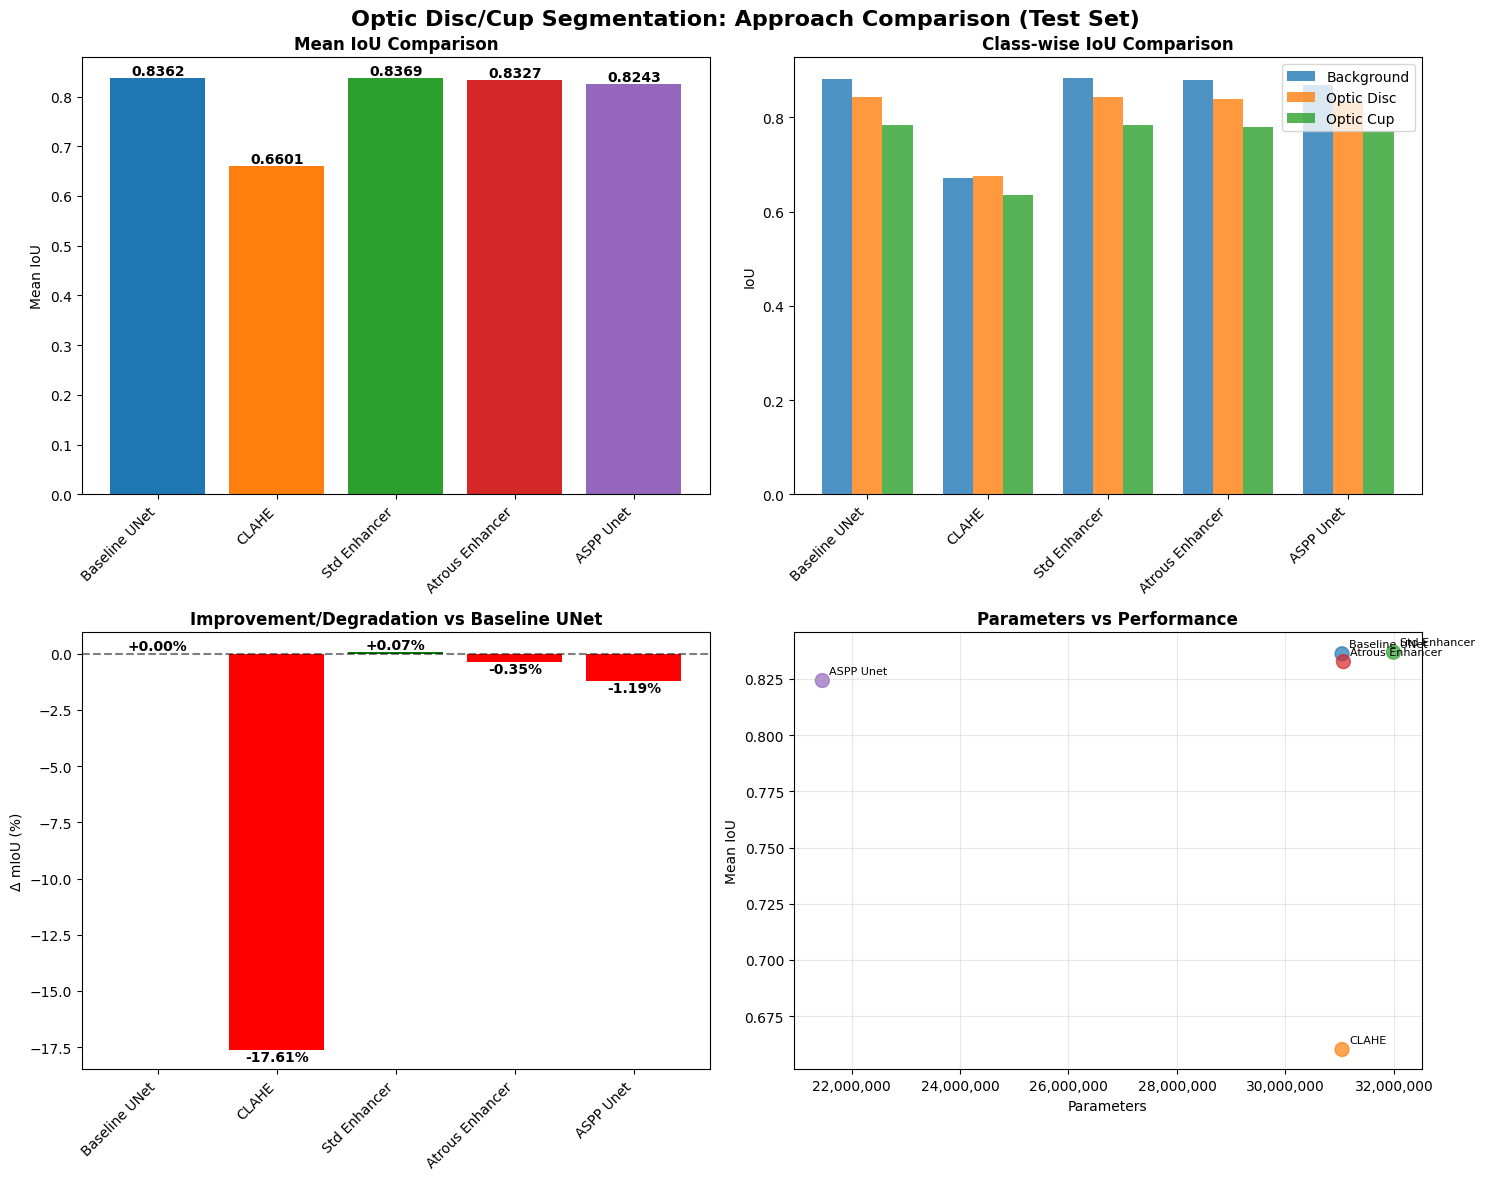

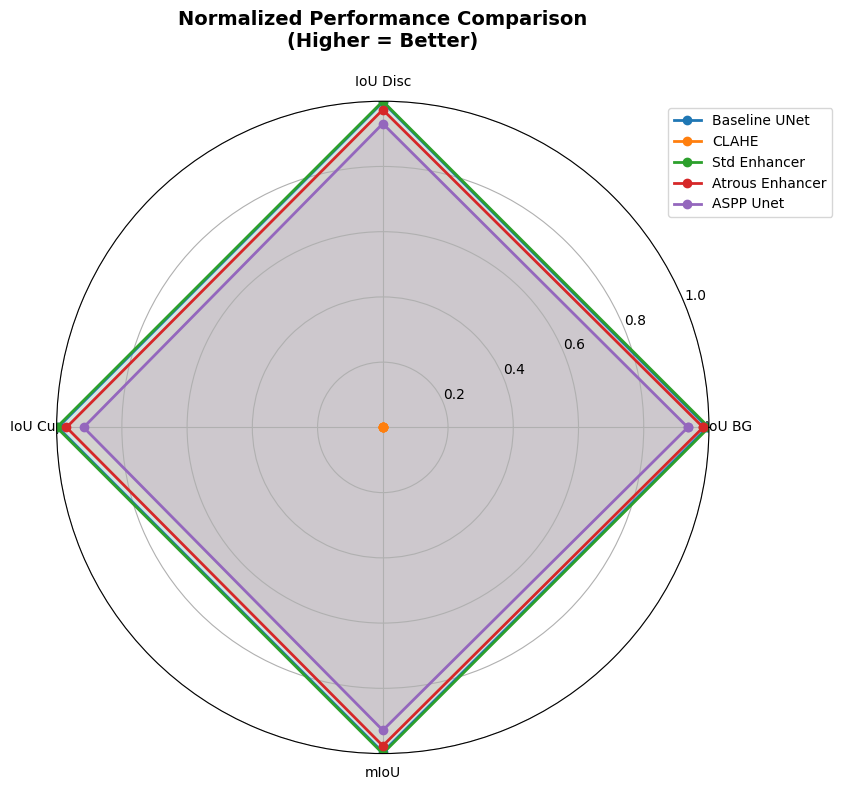


VISUALIZATION SUMMARY
Best performing model: Std Enhancer
.4f
.4f
Parameter range: 21,461,507 - 31,993,126


In [12]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Optic Disc/Cup Segmentation: Approach Comparison (Test Set)', fontsize=16, fontweight='bold')

# 1. Mean IoU comparison
iou_data = results_df[['miou']].copy()
iou_data['Approach'] = iou_data.index
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

ax1 = axes[0, 0]
bars = ax1.bar(range(len(iou_data)), iou_data['miou'], color=colors[:len(iou_data)])
ax1.set_title('Mean IoU Comparison', fontweight='bold')
ax1.set_ylabel('Mean IoU')
ax1.set_xticks(range(len(iou_data)))
ax1.set_xticklabels([display_names.get(label, label) for label in iou_data['Approach']], rotation=45, ha='right')

# Add value labels on bars
for bar, value in zip(bars, iou_data['miou']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Class-wise IoU comparison
class_iou = results_df[['iou_bg', 'iou_disc', 'iou_cup']].copy()
class_iou['Approach'] = class_iou.index

ax2 = axes[0, 1]
x = np.arange(len(class_iou))
width = 0.25

bars1 = ax2.bar(x - width, class_iou['iou_bg'], width, label='Background', color='#1f77b4', alpha=0.8)
bars2 = ax2.bar(x, class_iou['iou_disc'], width, label='Optic Disc', color='#ff7f0e', alpha=0.8)
bars3 = ax2.bar(x + width, class_iou['iou_cup'], width, label='Optic Cup', color='#2ca02c', alpha=0.8)

ax2.set_title('Class-wise IoU Comparison', fontweight='bold')
ax2.set_ylabel('IoU')
ax2.set_xticks(x)
ax2.set_xticklabels([display_names.get(label, label) for label in class_iou['Approach']], rotation=45, ha='right')
ax2.legend()

# 3. Improvement over baseline
delta_data = results_df[['delta_miou']].copy()
delta_data['Approach'] = delta_data.index

ax3 = axes[1, 0]
colors_delta = ['red' if x < 0 else 'green' for x in delta_data['delta_miou']]
bars = ax3.bar(range(len(delta_data)), delta_data['delta_miou'] * 100, color=colors_delta)
ax3.set_title('Improvement/Degradation vs Baseline UNet', fontweight='bold')
ax3.set_ylabel('Δ mIoU (%)')
ax3.set_xticks(range(len(delta_data)))
ax3.set_xticklabels([display_names.get(label, label) for label in delta_data['Approach']], rotation=45, ha='right')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Add value labels
for bar, value in zip(bars, delta_data['delta_miou'] * 100):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.02 if value >= 0 else -0.02),
             f'{value:+.2f}%', ha='center',
             va='bottom' if value >= 0 else 'top', fontweight='bold')

# 4. Parameters vs Performance
param_data = results_df[['parameters', 'miou']].copy()
param_data['Approach'] = param_data.index

ax4 = axes[1, 1]
scatter = ax4.scatter(param_data['parameters'], param_data['miou'],
                     s=100, c=colors[:len(param_data)], alpha=0.7)

# Add approach labels
for i, row in param_data.iterrows():
    ax4.annotate(display_names.get(row['Approach'], row['Approach']),
                (row['parameters'], row['miou']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax4.set_title('Parameters vs Performance', fontweight='bold')
ax4.set_xlabel('Parameters')
ax4.set_ylabel('Mean IoU')
ax4.grid(True, alpha=0.3)

# Format parameter axis
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

# Additional statistics plot - Radar chart
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw=dict(projection='polar'))

# Create a comprehensive metrics table plot
metrics_to_plot = ['iou_bg', 'iou_disc', 'iou_cup', 'miou']
plot_data = results_df[metrics_to_plot].copy()

# Normalize each metric to 0-1 scale for comparison
normalized_data = plot_data.copy()
for col in plot_data.columns:
    normalized_data[col] = (plot_data[col] - plot_data[col].min()) / (plot_data[col].max() - plot_data[col].min())

# Plot radar chart style comparison
angles = np.linspace(0, 2 * np.pi, len(metrics_to_plot), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

for i, approach in enumerate(normalized_data.index):
    values = normalized_data.loc[approach].values.tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, 'o-', linewidth=2, label=display_names.get(approach, approach),
            color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['IoU BG', 'IoU Disc', 'IoU Cup', 'mIoU'])
ax.set_ylim(0, 1)
ax.set_title('Normalized Performance Comparison\n(Higher = Better)', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
ax.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("VISUALIZATION SUMMARY")
print("="*80)
print(f"Best performing model: {display_names.get(ranked_results.index[0], ranked_results.index[0])}")
print(".4f")
print(".4f")
print(f"Parameter range: {results_df['parameters'].min():,} - {results_df['parameters'].max():,}")
print("="*80)

## 14. Save Results to JSON


SAMPLE 13 METRICS
Baseline UNet - BG: 0.7704, Disc: 0.7722, Cup: 0.6236, mIoU: 0.7220
ASPP-UNet     - BG: 0.8265, Disc: 0.7963, Cup: 0.5992, mIoU: 0.7407

SAMPLE 52 METRICS
Baseline UNet - BG: 0.9066, Disc: 0.2625, Cup: 0.2321, mIoU: 0.4670
ASPP-UNet     - BG: 0.8933, Disc: 0.2765, Cup: 0.2897, mIoU: 0.4865

SAMPLE 56 METRICS
Baseline UNet - BG: 0.9055, Disc: 0.5969, Cup: 0.8512, mIoU: 0.7845
ASPP-UNet     - BG: 0.9425, Disc: 0.5717, Cup: 0.7605, mIoU: 0.7582

SAMPLE 160 METRICS
Baseline UNet - BG: 0.8755, Disc: 0.9074, Cup: 0.8085, mIoU: 0.8638
ASPP-UNet     - BG: 0.8442, Disc: 0.8991, Cup: 0.8288, mIoU: 0.8573


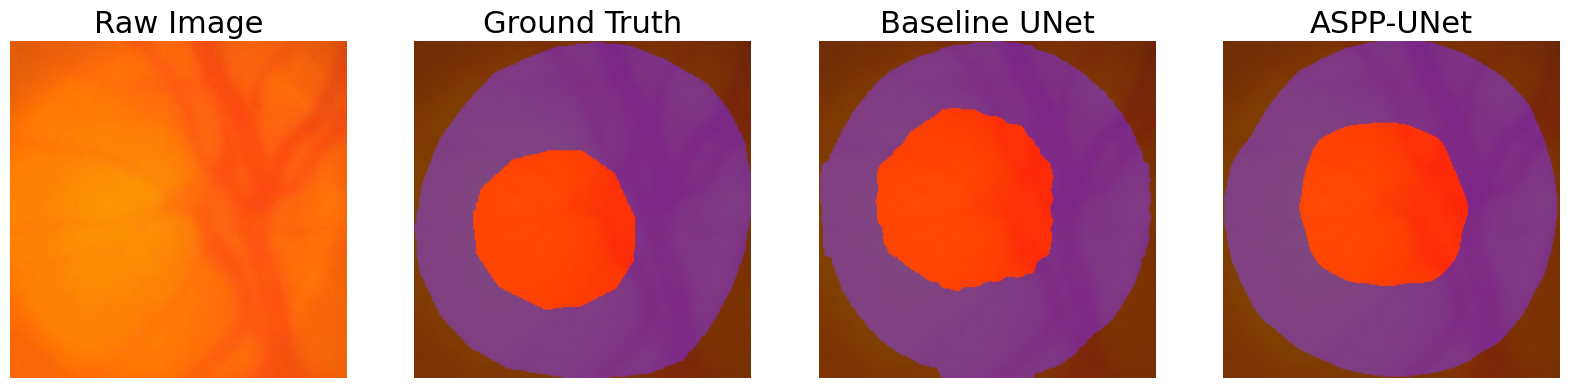

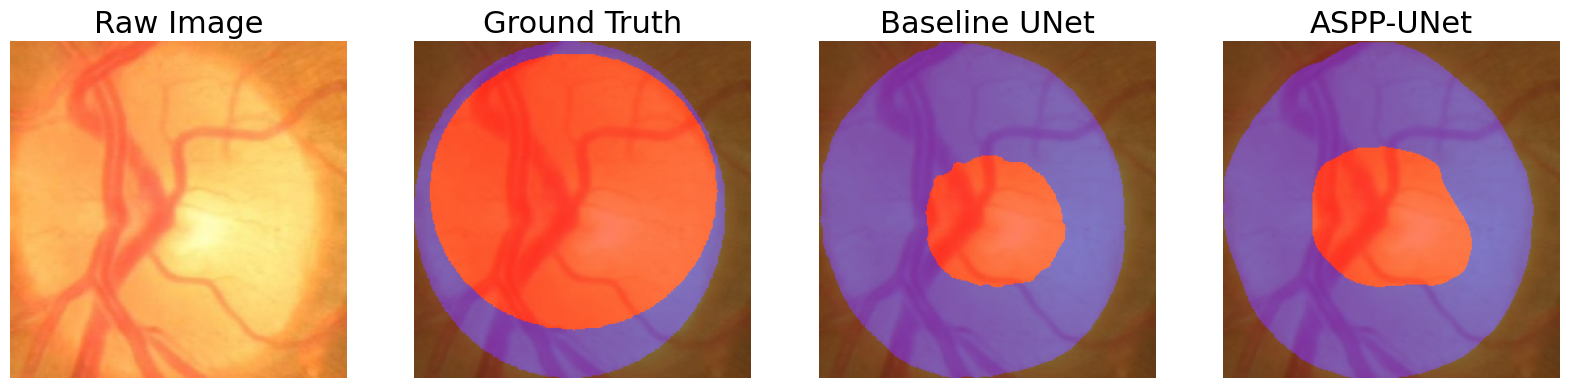

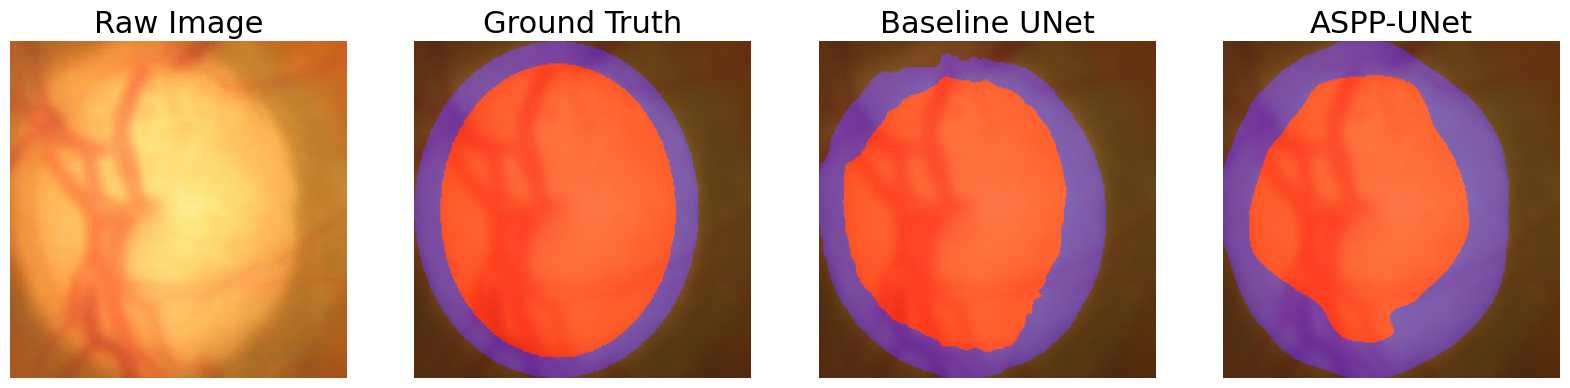

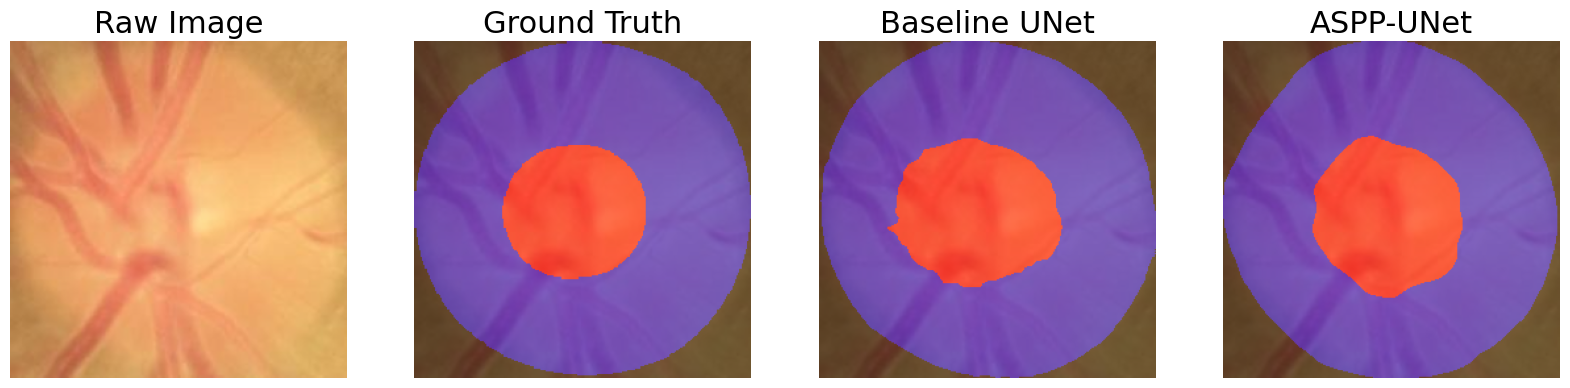

In [17]:
# Define sample indices to visualize
sample_indices = [
    13,
    52,
    56,
    160  # fritty/frayed edges
]

for random_idx in sample_indices:
    # Get the sample
    sample_image, sample_mask = test_dataset[random_idx]

    # Convert to batch format for model input
    sample_image_batch = sample_image.unsqueeze(0).to(device)

    # Get predictions from Baseline UNet and ASPP-UNet
    with torch.no_grad():
        baseline_pred = models['baseline_unet'](sample_image_batch)
        aspp_pred = models['aspp_unet'](sample_image_batch)

    # Convert predictions to class labels
    baseline_pred_mask = torch.argmax(
        baseline_pred, dim=1).squeeze().cpu().numpy()
    aspp_pred_mask = torch.argmax(aspp_pred, dim=1).squeeze().cpu().numpy()

    # Convert image and ground truth for visualization
    sample_image_np = sample_image.permute(1, 2, 0).cpu().numpy()
    # Denormalize if needed (assuming ImageNet normalization)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample_image_np = sample_image_np * std + mean
    sample_image_np = np.clip(sample_image_np, 0, 1)

    sample_mask_np = sample_mask.cpu().numpy()

    # Create color map for segmentation masks
    # 0: Background (black), 1: Optic Disc (blue), 2: Optic Cup (red)
    def mask_to_rgb(mask):
        rgb = np.zeros((mask.shape[0], mask.shape[1], 3))
        rgb[mask == 1] = [0, 0, 1]  # Blue for disc
        rgb[mask == 2] = [1, 0, 0]  # Red for cup
        return rgb

    gt_rgb = mask_to_rgb(sample_mask_np)
    baseline_rgb = mask_to_rgb(baseline_pred_mask)
    aspp_rgb = mask_to_rgb(aspp_pred_mask)

    # Create visualization
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    TITLE_FONT_SIZE = 22
    TITLE_FONT_WEIGHT = 'normal'

    # 1. Raw Image
    axes[0].imshow(sample_image_np)
    axes[0].set_title('Raw Image', fontweight=TITLE_FONT_WEIGHT,
                      fontsize=TITLE_FONT_SIZE)
    axes[0].axis('off')

    # 2. Ground Truth
    axes[1].imshow(sample_image_np)
    axes[1].imshow(gt_rgb, alpha=0.5)
    axes[1].set_title(
        'Ground Truth', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[1].axis('off')

    # 3. Baseline UNet Prediction
    axes[2].imshow(sample_image_np)
    axes[2].imshow(baseline_rgb, alpha=0.5)
    axes[2].set_title(f'Baseline UNet',
                      fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[2].axis('off')

    # 4. ASPP-UNet Prediction
    axes[3].imshow(sample_image_np)
    axes[3].imshow(aspp_rgb, alpha=0.5)
    axes[3].set_title(f'ASPP-UNet', fontweight=TITLE_FONT_WEIGHT,
                      fontsize=TITLE_FONT_SIZE)
    axes[3].axis('off')

    output_file = project_root / 'results' / \
        f'sample_comparison_{random_idx}.png'

    plt.savefig(str(output_file), bbox_inches='tight')
    # plt.show()

    # Calculate IoU for this specific sample
    baseline_sample_iou = calculate_iou_per_class(
        torch.tensor(baseline_pred_mask), torch.tensor(sample_mask_np))
    aspp_sample_iou = calculate_iou_per_class(
        torch.tensor(aspp_pred_mask), torch.tensor(sample_mask_np))

    print("\n" + "="*80)
    print(f"SAMPLE {random_idx} METRICS")
    print("="*80)
    print(
        f"Baseline UNet - BG: {baseline_sample_iou[0]:.4f}, Disc: {baseline_sample_iou[1]:.4f}, Cup: {baseline_sample_iou[2]:.4f}, mIoU: {np.mean(baseline_sample_iou):.4f}")
    print(
        f"ASPP-UNet     - BG: {aspp_sample_iou[0]:.4f}, Disc: {aspp_sample_iou[1]:.4f}, Cup: {aspp_sample_iou[2]:.4f}, mIoU: {np.mean(aspp_sample_iou):.4f}")
    print("="*80)

## 16. Save Results to JSON

In [16]:
# Save results to JSON
output_file = project_root / 'results' / 'test_comparison.json'

# Convert to JSON-serializable format
json_results = {}
for model_name, metrics in all_results.items():
    json_results[model_name] = {k: float(v) for k, v in metrics.items()}

with open(output_file, 'w') as f:
    json.dump(json_results, f, indent=2)

print(f"Results saved to: {output_file}")

Results saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/test_comparison.json


# Comprehensive Model Comparison: Optic Disc/Cup Segmentation

This notebook evaluates and compares five different approaches for optic disc and cup segmentation on the test dataset.

**Approaches:**
1. **Baseline UNet** - Standard UNet architecture
2. **CLAHE** - UNet trained with CLAHE preprocessing
3. **Baseline + Std Enhancer** - UNet with learned standard enhancer
4. **Baseline + Atrous Enhancer** - UNet with learned multi-scale enhancer
5. **ASPP Unet** - UNet with Atrous Spatial Pyramid Pooling

**Metrics:**
- Loss, IoU BG, IoU Disc, IoU Cup, mIoU, Parameters, Δ mIoU

## 13. Enhancer Visualization: Raw vs Enhanced vs Difference

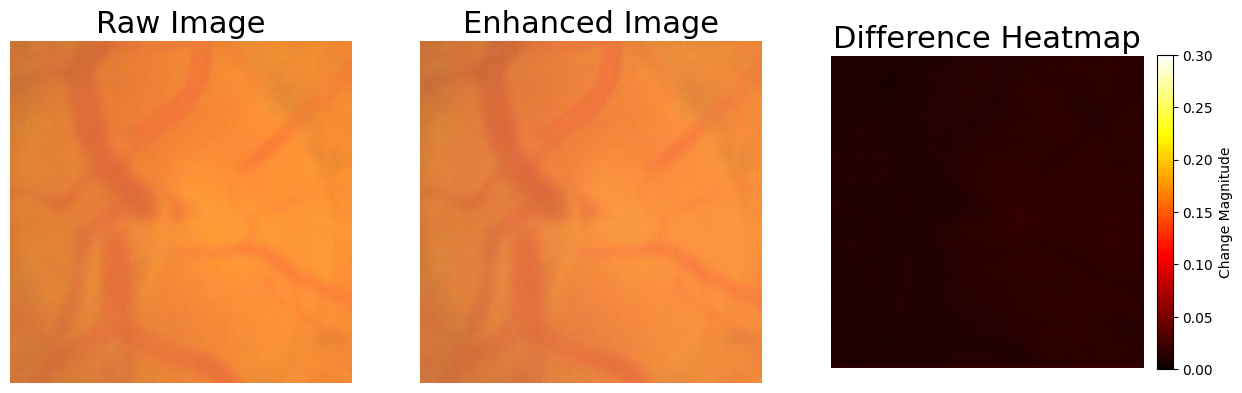

Standard Enhancer - Mean absolute difference: 0.0136
Standard Enhancer - Max difference: 0.0280
Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/std_enhancer_visualization_100.png


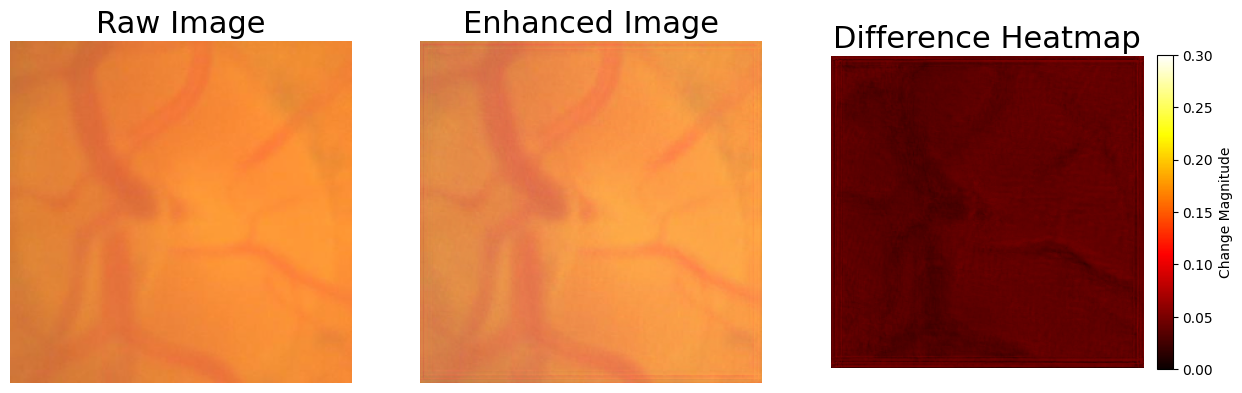


Atrous Enhancer - Mean absolute difference: 0.0369
Atrous Enhancer - Max difference: 0.0593
Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_visualization_100.png


In [23]:
# Visualize how the enhancers work on sample 100
enhancer_sample_idx = 100

# Get the sample
sample_image, sample_mask = test_dataset[enhancer_sample_idx]
sample_image_batch = sample_image.unsqueeze(0).to(device)

# Denormalize function
def denormalize_image(img_tensor):
    """Denormalize image tensor for visualization"""
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = img_np * std + mean
    img_np = np.clip(img_np, 0, 1)
    return img_np

# Get raw image
raw_image_np = denormalize_image(sample_image)

# Get enhanced images from both enhancers
with torch.no_grad():
    # Standard Enhancer
    std_enhanced, _ = models['std_enhancer'](sample_image_batch)
    std_enhanced_np = denormalize_image(std_enhanced.squeeze())
    
    # Atrous Enhancer
    atrous_enhanced, _ = models['atrous_enhancer'](sample_image_batch)
    atrous_enhanced_np = denormalize_image(atrous_enhanced.squeeze())

# Calculate differences (highlight changes)
std_diff = np.abs(std_enhanced_np - raw_image_np)
atrous_diff = np.abs(atrous_enhanced_np - raw_image_np)

# Convert to magnitude (average across RGB channels for better visualization)
std_diff_magnitude = np.mean(std_diff, axis=2)
atrous_diff_magnitude = np.mean(atrous_diff, axis=2)

TITLE_FONT_SIZE = 22
TITLE_FONT_WEIGHT = 'normal'

# Visualization 1: Standard Enhancer
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_image_np)
axes[0].set_title('Raw Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
axes[0].axis('off')

axes[1].imshow(std_enhanced_np)
axes[1].set_title('Enhanced Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
axes[1].axis('off')

# Show difference as heatmap - hot colormap (black=no change, red/yellow/white=more change)
im = axes[2].imshow(std_diff_magnitude, cmap='hot', vmin=0, vmax=0.3)
axes[2].set_title('Difference Heatmap', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Change Magnitude')

output_file = project_root / 'results' / f'std_enhancer_visualization_{enhancer_sample_idx}.png'
plt.savefig(str(output_file), bbox_inches='tight', dpi=300)
plt.show()

print(f"Standard Enhancer - Mean absolute difference: {std_diff_magnitude.mean():.4f}")
print(f"Standard Enhancer - Max difference: {std_diff_magnitude.max():.4f}")
print(f"Saved to: {output_file}")

# Visualization 2: Atrous Enhancer
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(raw_image_np)
axes[0].set_title('Raw Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
axes[0].axis('off')

axes[1].imshow(atrous_enhanced_np)
axes[1].set_title('Enhanced Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
axes[1].axis('off')

# Show difference as heatmap - hot colormap (black=no change, red/yellow/white=more change)
im = axes[2].imshow(atrous_diff_magnitude, cmap='hot', vmin=0, vmax=0.3)
axes[2].set_title('Difference Heatmap', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Change Magnitude')

output_file = project_root / 'results' / f'atrous_enhancer_visualization_{enhancer_sample_idx}.png'
plt.savefig(str(output_file), bbox_inches='tight', dpi=300)
plt.show()

print(f"\nAtrous Enhancer - Mean absolute difference: {atrous_diff_magnitude.mean():.4f}")
print(f"Atrous Enhancer - Max difference: {atrous_diff_magnitude.max():.4f}")
print(f"Saved to: {output_file}")

## 14. Find Best Performing Samples for Each Enhancer

In [24]:
# Find the samples where each enhancer performs best compared to baseline
print("Finding best performing samples for each enhancer...")

# Store per-sample metrics
baseline_sample_ious = []
std_enhancer_sample_ious = []
atrous_enhancer_sample_ious = []

with torch.no_grad():
    for idx in tqdm(range(len(test_dataset)), desc='Evaluating all samples'):
        sample_image, sample_mask = test_dataset[idx]
        sample_image_batch = sample_image.unsqueeze(0).to(device)
        sample_mask_np = sample_mask.cpu().numpy()
        
        # Baseline prediction
        baseline_pred = models['baseline_unet'](sample_image_batch)
        baseline_pred_mask = torch.argmax(baseline_pred, dim=1).squeeze().cpu().numpy()
        baseline_iou = calculate_iou_per_class(torch.tensor(baseline_pred_mask), torch.tensor(sample_mask_np))
        baseline_miou = np.mean(baseline_iou)
        baseline_sample_ious.append(baseline_miou)
        
        # Standard Enhancer prediction
        std_enhanced, std_pred = models['std_enhancer'](sample_image_batch)
        std_pred_mask = torch.argmax(std_pred, dim=1).squeeze().cpu().numpy()
        std_iou = calculate_iou_per_class(torch.tensor(std_pred_mask), torch.tensor(sample_mask_np))
        std_miou = np.mean(std_iou)
        std_enhancer_sample_ious.append(std_miou)
        
        # Atrous Enhancer prediction
        atrous_enhanced, atrous_pred = models['atrous_enhancer'](sample_image_batch)
        atrous_pred_mask = torch.argmax(atrous_pred, dim=1).squeeze().cpu().numpy()
        atrous_iou = calculate_iou_per_class(torch.tensor(atrous_pred_mask), torch.tensor(sample_mask_np))
        atrous_miou = np.mean(atrous_iou)
        atrous_enhancer_sample_ious.append(atrous_miou)

# Calculate improvements
baseline_sample_ious = np.array(baseline_sample_ious)
std_enhancer_sample_ious = np.array(std_enhancer_sample_ious)
atrous_enhancer_sample_ious = np.array(atrous_enhancer_sample_ious)

std_improvements = std_enhancer_sample_ious - baseline_sample_ious
atrous_improvements = atrous_enhancer_sample_ious - baseline_sample_ious

# Find best samples
best_std_idx = np.argmax(std_improvements)
best_atrous_idx = np.argmax(atrous_improvements)

print("\n" + "="*80)
print("BEST PERFORMING SAMPLES")
print("="*80)
print(f"\nStandard Enhancer:")
print(f"  Best sample index: {best_std_idx}")
print(f"  Baseline mIoU: {baseline_sample_ious[best_std_idx]:.4f}")
print(f"  Std Enhancer mIoU: {std_enhancer_sample_ious[best_std_idx]:.4f}")
print(f"  Improvement: +{std_improvements[best_std_idx]:.4f} ({std_improvements[best_std_idx]*100:.2f}%)")

print(f"\nAtrous Enhancer:")
print(f"  Best sample index: {best_atrous_idx}")
print(f"  Baseline mIoU: {baseline_sample_ious[best_atrous_idx]:.4f}")
print(f"  Atrous Enhancer mIoU: {atrous_enhancer_sample_ious[best_atrous_idx]:.4f}")
print(f"  Improvement: +{atrous_improvements[best_atrous_idx]:.4f} ({atrous_improvements[best_atrous_idx]*100:.2f}%)")

# Find top 5 for each
print("\n" + "-"*80)
print("TOP 5 SAMPLES FOR STANDARD ENHANCER:")
print("-"*80)
top5_std = np.argsort(std_improvements)[-5:][::-1]
for rank, idx in enumerate(top5_std, 1):
    print(f"{rank}. Sample {idx}: Baseline={baseline_sample_ious[idx]:.4f}, "
          f"Std Enhancer={std_enhancer_sample_ious[idx]:.4f}, "
          f"Improvement=+{std_improvements[idx]:.4f}")

print("\n" + "-"*80)
print("TOP 5 SAMPLES FOR ATROUS ENHANCER:")
print("-"*80)
top5_atrous = np.argsort(atrous_improvements)[-5:][::-1]
for rank, idx in enumerate(top5_atrous, 1):
    print(f"{rank}. Sample {idx}: Baseline={baseline_sample_ious[idx]:.4f}, "
          f"Atrous Enhancer={atrous_enhancer_sample_ious[idx]:.4f}, "
          f"Improvement=+{atrous_improvements[idx]:.4f}")

print("="*80)

Finding best performing samples for each enhancer...


Evaluating all samples: 100%|██████████| 396/396 [00:13<00:00, 28.59it/s]


BEST PERFORMING SAMPLES

Standard Enhancer:
  Best sample index: 139
  Baseline mIoU: 0.8035
  Std Enhancer mIoU: 0.8396
  Improvement: +0.0361 (3.61%)

Atrous Enhancer:
  Best sample index: 56
  Baseline mIoU: 0.7845
  Atrous Enhancer mIoU: 0.8514
  Improvement: +0.0669 (6.69%)

--------------------------------------------------------------------------------
TOP 5 SAMPLES FOR STANDARD ENHANCER:
--------------------------------------------------------------------------------
1. Sample 139: Baseline=0.8035, Std Enhancer=0.8396, Improvement=+0.0361
2. Sample 3: Baseline=0.8158, Std Enhancer=0.8462, Improvement=+0.0304
3. Sample 200: Baseline=0.8690, Std Enhancer=0.8993, Improvement=+0.0303
4. Sample 13: Baseline=0.7220, Std Enhancer=0.7502, Improvement=+0.0281
5. Sample 391: Baseline=0.7888, Std Enhancer=0.8150, Improvement=+0.0262

--------------------------------------------------------------------------------
TOP 5 SAMPLES FOR ATROUS ENHANCER:
----------------------------------------

## 15. Visualize Best Enhancer Samples


VISUALIZING TOP 5 SAMPLES FOR STANDARD ENHANCER

[1/5] Visualizing Standard Enhancer - Sample 139
  Improvement: +0.0361


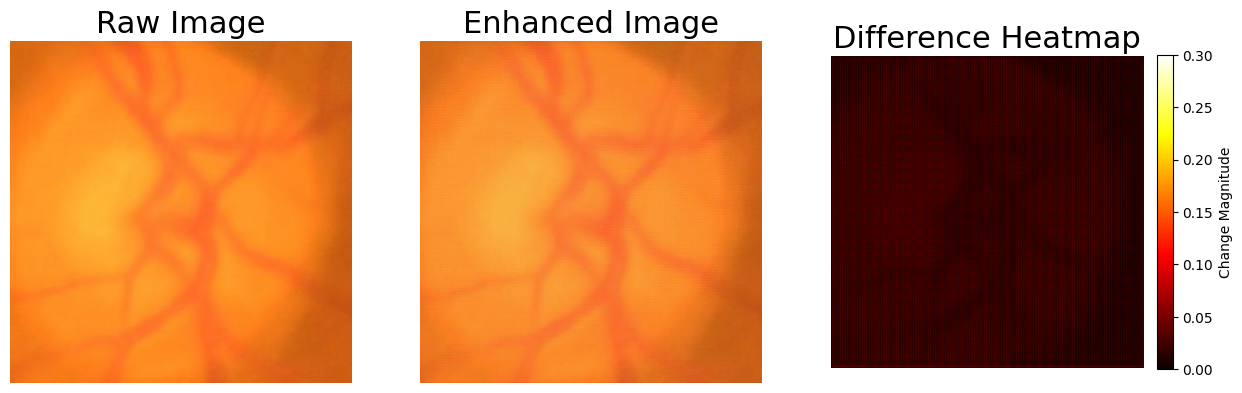

  Mean absolute difference: 0.0187
  Max difference: 0.0366
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/std_enhancer_top1_sample_139.png

[2/5] Visualizing Standard Enhancer - Sample 3
  Improvement: +0.0304


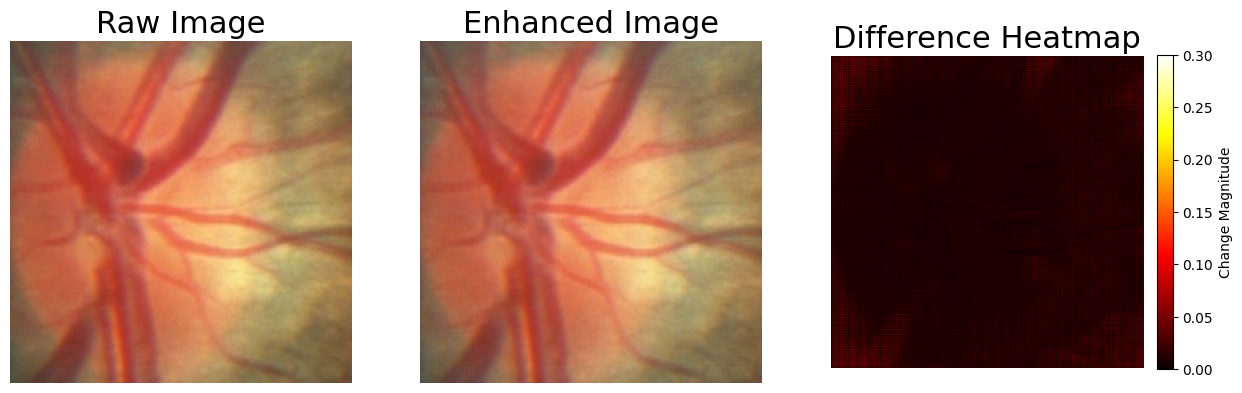

  Mean absolute difference: 0.0118
  Max difference: 0.0512
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/std_enhancer_top2_sample_3.png

[3/5] Visualizing Standard Enhancer - Sample 200
  Improvement: +0.0303


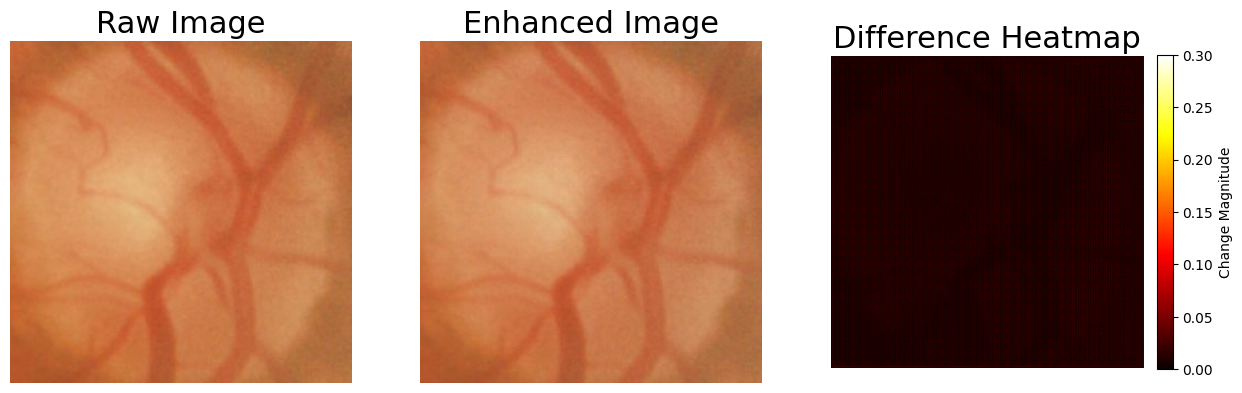

  Mean absolute difference: 0.0103
  Max difference: 0.0242
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/std_enhancer_top3_sample_200.png

[4/5] Visualizing Standard Enhancer - Sample 13
  Improvement: +0.0281


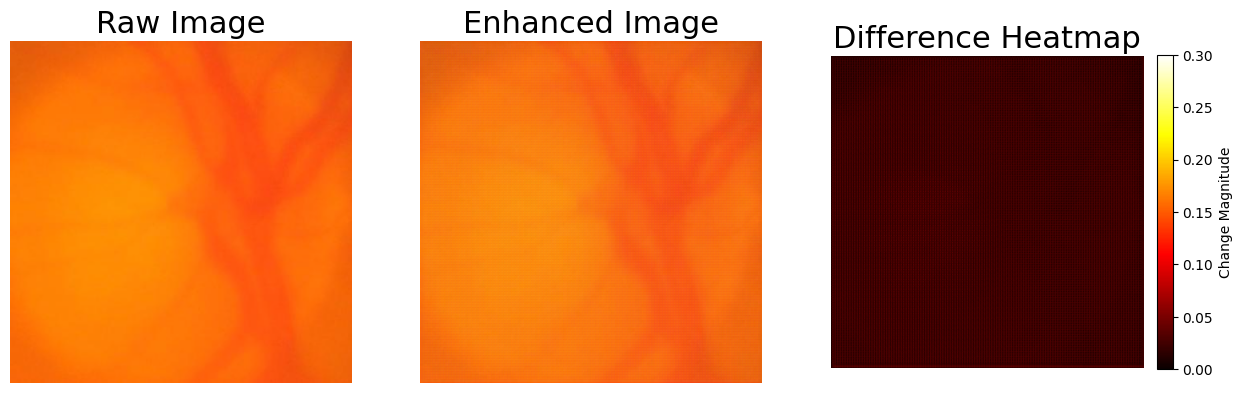

  Mean absolute difference: 0.0229
  Max difference: 0.0406
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/std_enhancer_top4_sample_13.png

[5/5] Visualizing Standard Enhancer - Sample 391
  Improvement: +0.0262


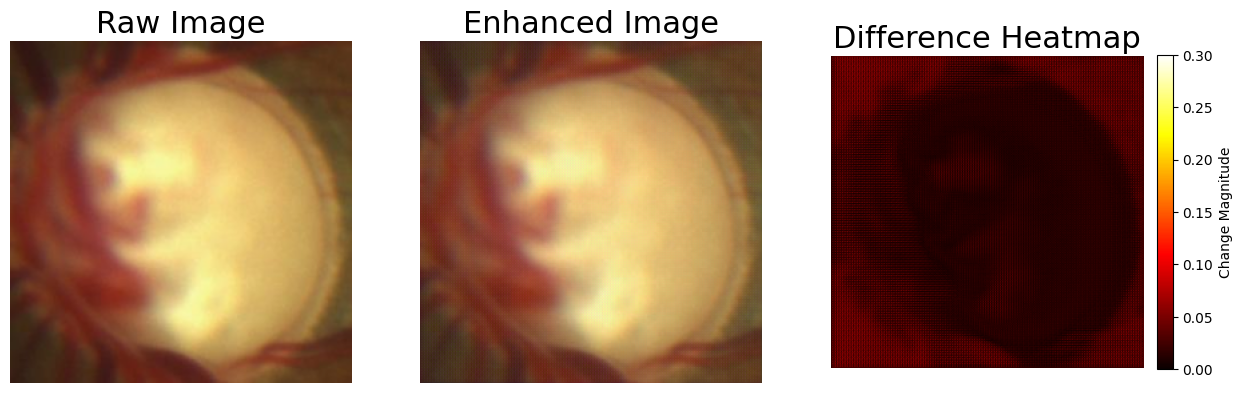

  Mean absolute difference: 0.0193
  Max difference: 0.0619
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/std_enhancer_top5_sample_391.png

VISUALIZING TOP 5 SAMPLES FOR ATROUS ENHANCER

[1/5] Visualizing Atrous Enhancer - Sample 56
  Improvement: +0.0669


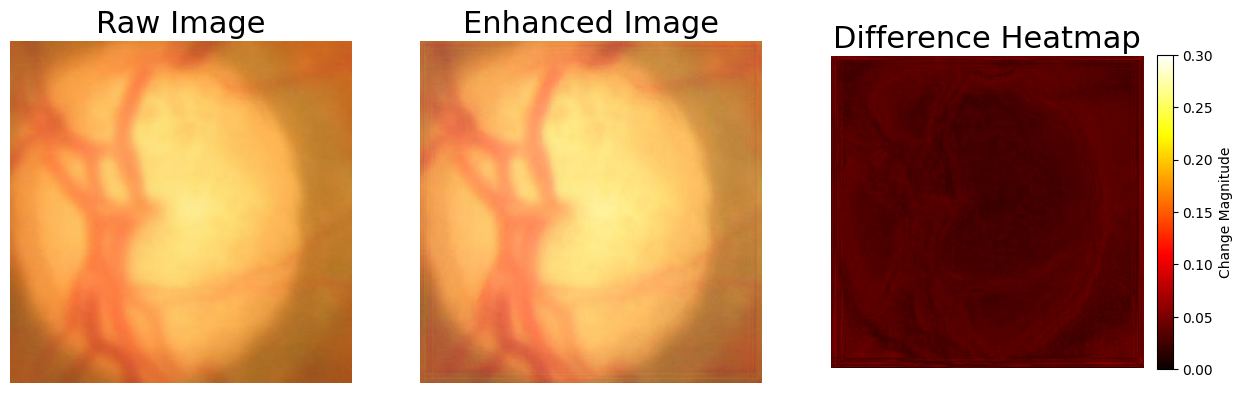

  Mean absolute difference: 0.0318
  Max difference: 0.0591
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_top1_sample_56.png

[2/5] Visualizing Atrous Enhancer - Sample 391
  Improvement: +0.0655


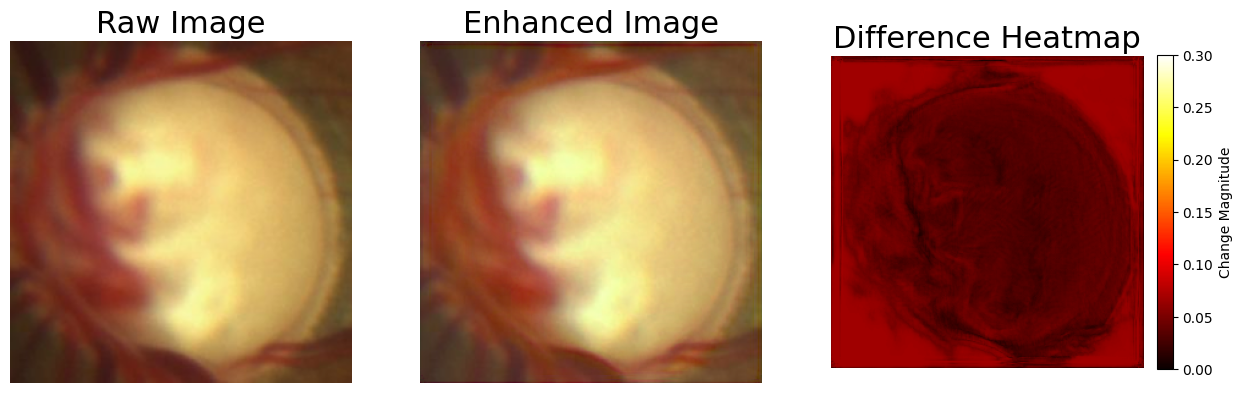

  Mean absolute difference: 0.0435
  Max difference: 0.0678
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_top2_sample_391.png

[3/5] Visualizing Atrous Enhancer - Sample 73
  Improvement: +0.0481


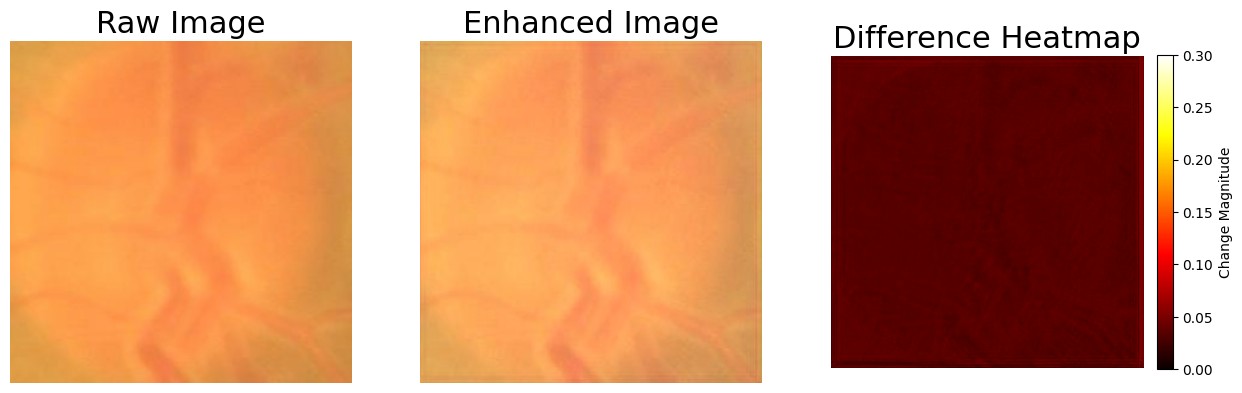

  Mean absolute difference: 0.0348
  Max difference: 0.0567
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_top3_sample_73.png

[4/5] Visualizing Atrous Enhancer - Sample 304
  Improvement: +0.0419


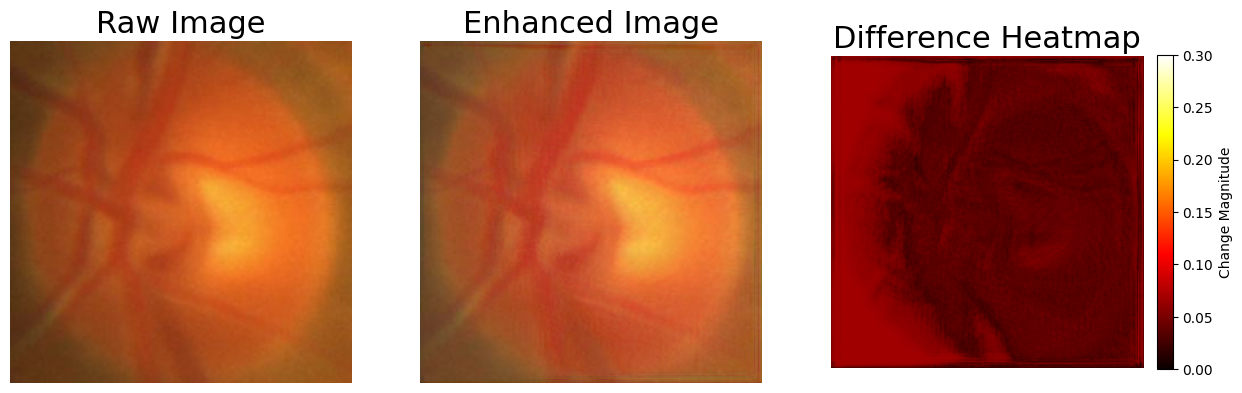

  Mean absolute difference: 0.0433
  Max difference: 0.0678
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_top4_sample_304.png

[5/5] Visualizing Atrous Enhancer - Sample 394
  Improvement: +0.0404


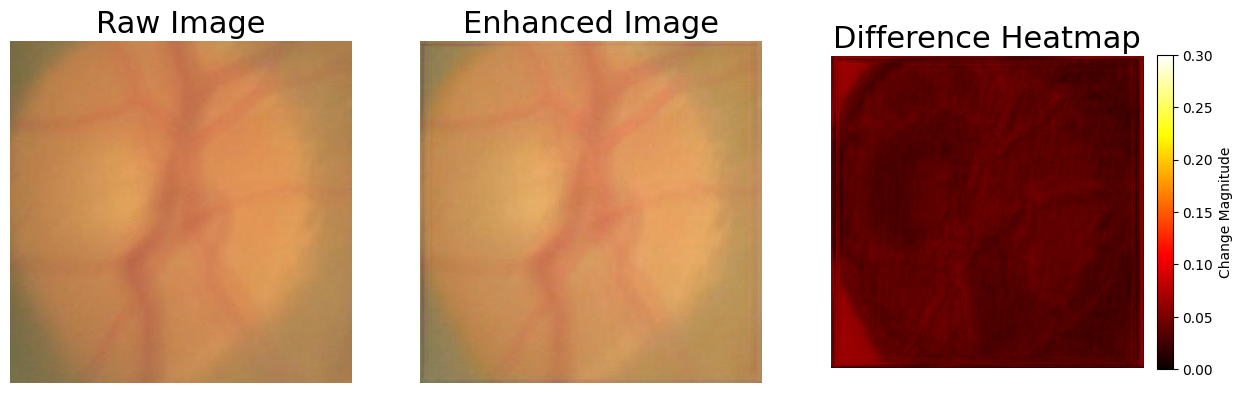

  Mean absolute difference: 0.0358
  Max difference: 0.0667
  Saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/atrous_enhancer_top5_sample_394.png

COMPLETED VISUALIZATIONS FOR TOP 5 SAMPLES


In [ ]:
# Visualize the top 5 best performing samples for Standard Enhancer
print("\n" + "="*80)
print("VISUALIZING TOP 5 SAMPLES FOR STANDARD ENHANCER")
print("="*80)

for rank, sample_idx in enumerate(top5_std, 1):
    print(f"\n[{rank}/5] Visualizing Standard Enhancer - Sample {sample_idx}")
    print(f"  Improvement: +{std_improvements[sample_idx]:.4f}")
    
    sample_image, sample_mask = test_dataset[sample_idx]
    sample_image_batch = sample_image.unsqueeze(0).to(device)
    
    # Get raw image
    raw_image_np = denormalize_image(sample_image)
    
    # Get enhanced image and prediction
    with torch.no_grad():
        std_enhanced, _ = models['std_enhancer'](sample_image_batch)
        std_enhanced_np = denormalize_image(std_enhanced.squeeze())
    
    # Calculate difference - use magnitude across all channels
    std_diff = np.abs(std_enhanced_np - raw_image_np)
    std_diff_magnitude = np.mean(std_diff, axis=2)  # Average across RGB channels
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(raw_image_np)
    axes[0].set_title('Raw Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[0].axis('off')
    
    axes[1].imshow(std_enhanced_np)
    axes[1].set_title('Enhanced Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[1].axis('off')
    
    # Show difference as heatmap (warmer colors = more change)
    im = axes[2].imshow(std_diff_magnitude, cmap='hot', vmin=0, vmax=0.3)
    axes[2].set_title('Difference Heatmap', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Change Magnitude')
    
    output_file = project_root / 'results' / f'std_enhancer_top{rank}_sample_{sample_idx}.png'
    plt.savefig(str(output_file), bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"  Mean absolute difference: {std_diff_magnitude.mean():.4f}")
    print(f"  Max difference: {std_diff_magnitude.max():.4f}")
    print(f"  Saved to: {output_file}")

# Visualize the top 5 best performing samples for Atrous Enhancer
print("\n" + "="*80)
print("VISUALIZING TOP 5 SAMPLES FOR ATROUS ENHANCER")
print("="*80)

for rank, sample_idx in enumerate(top5_atrous, 1):
    print(f"\n[{rank}/5] Visualizing Atrous Enhancer - Sample {sample_idx}")
    print(f"  Improvement: +{atrous_improvements[sample_idx]:.4f}")
    
    sample_image, sample_mask = test_dataset[sample_idx]
    sample_image_batch = sample_image.unsqueeze(0).to(device)
    
    # Get raw image
    raw_image_np = denormalize_image(sample_image)
    
    # Get enhanced image and prediction
    with torch.no_grad():
        atrous_enhanced, _ = models['atrous_enhancer'](sample_image_batch)
        atrous_enhanced_np = denormalize_image(atrous_enhanced.squeeze())
    
    # Calculate difference - use magnitude across all channels
    atrous_diff = np.abs(atrous_enhanced_np - raw_image_np)
    atrous_diff_magnitude = np.mean(atrous_diff, axis=2)  # Average across RGB channels
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(raw_image_np)
    axes[0].set_title('Raw Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[0].axis('off')
    
    axes[1].imshow(atrous_enhanced_np)
    axes[1].set_title('Enhanced Image', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[1].axis('off')
    
    # Show difference as heatmap (warmer colors = more change)
    im = axes[2].imshow(atrous_diff_magnitude, cmap='hot', vmin=0, vmax=0.3)
    axes[2].set_title('Difference Heatmap', fontweight=TITLE_FONT_WEIGHT, fontsize=TITLE_FONT_SIZE)
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Change Magnitude')
    
    output_file = project_root / 'results' / f'atrous_enhancer_top{rank}_sample_{sample_idx}.png'
    plt.savefig(str(output_file), bbox_inches='tight', dpi=300)
    plt.show()
    
    print(f"  Mean absolute difference: {atrous_diff_magnitude.mean():.4f}")
    print(f"  Max difference: {atrous_diff_magnitude.max():.4f}")
    print(f"  Saved to: {output_file}")

print("\n" + "="*80)
print("COMPLETED VISUALIZATIONS FOR TOP 5 SAMPLES")
print("="*80)